<a href="https://colab.research.google.com/github/Leo-Mtz/mineria-de-datos/blob/main/177192_naming_colors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
#Leo Martinez-177192

# Naming colors

If you are shown random colors evenly spaced across the color spectrum, what percentage of those colors would the average person name red? What about green?

English speakers in the United States were shown 80 color chips in random order in controlled lighting condtions. These 80 colors are evenly spaced across the standard Munsell array of colors. The participants were told: "There are 11 choices: black, white, red, green, blue, purple, brown, yellow, orange, pink, gray. Choose the closest color word".

This study was then repeated with Bolivian-Spanish speakers in Bolivia and Tsimane' speakers from the Amazon.

The dataset `munsell-array-fixed-choice.csv` shows the most common name in each language for each color chip.

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("/content/drive/MyDrive/munsell-array-fixed-choice.csv")
df.head()

,grid,x,y,munsell_code,tile_hex,english_color,spanish_color,tsimane_color,spanish,tsimane
0,B1,1,7,5R8/6,#fbb6b0,pink,pink,yellow,rosada (pink),chamus (yellow)
1,D1,1,5,5R6/12,#eb6a68,pink,pink,red,rosada (pink),jainas (red)
2,F1,1,3,5R4/14,#bb1933,red,red,red,rojo (red),jainas (red)
3,H1,1,1,5R2/8,#610d25,red,red,brown,rojo (red),cafedyeisi (brown)
4,A2,2,8,10R9/2,#f2ded8,pink,white,white,blanco (white),jaibas (white)


The function below plots the 80 evenly spaced colors that each study participant was shown in random order.

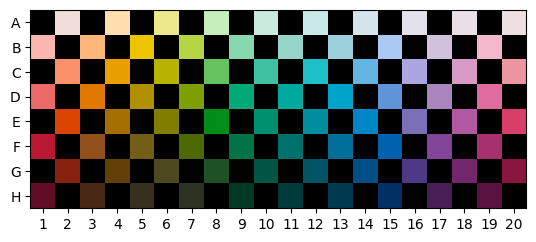

In [17]:
def plot_colors(color_column):
    fig, ax = plt.subplots()
    for idx, row in df.iterrows():
        ax.add_patch(plt.Rectangle((row['x'] - 0.5, row['y'] - 0.5), 1, 1, color=row[color_column], linewidth=0))

    ax.set_xlim(0.5, 20.5)
    ax.set_ylim(0.5, 8.5)
    ax.set_aspect('equal')
    ax.set_facecolor('black')
    ax.set_xticks(range(1, 21))
    ax.set_yticks(range(1, 9), ['H', 'G', 'F', 'E', 'D', 'C', 'B', 'A'])

plot_colors('tile_hex')

We can also use this function to plot the most common name in each language for each color chip.

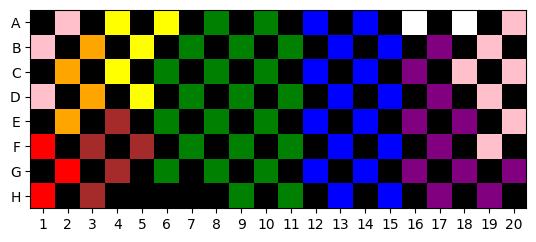

In [18]:
# Also try 'spanish_color' and 'tsimane_color'
plot_colors('english_color')

### Project Ideas:

- For each language, calculate what percentage of chips are named each color. Return dataframes for each language.

- Create a horizontal bar plot for each language. Each bar represents a color name and the length encodes the percentage of chips that are named that color.

- Is there a correlation between languages? Create scatter plots.
	- Hint: the x-axis could be the percentage of chips for English speakers and the y-axis could be the percentage of chips for Tsimane speakers and each data point represents a color name.

	- You might need to `merge` dataframes.


In [19]:
# Calculo de porcentaje de cada lenguaje
def get_color_percentages(column_name):
    counts = df[column_name].value_counts()
    percentages = (counts / len(df) * 100).reset_index()
    percentages.columns = ['color', 'percentage']
    return percentages

# Creacion de dataframe
english_pct = get_color_percentages('english_color')
spanish_pct = get_color_percentages('spanish_color')
tsimane_pct = get_color_percentages('tsimane_color')

# Dataframes por lenguaje
print("Porcentaje de colores en ingles:")
display(english_pct)

print("\nPorcentaje de colores en espanol:")
display(spanish_pct)

print("\nPorcentaje de colores en Tsimane:")
display(tsimane_pct)

Porcentaje de colores en ingles:


,color,percentage
0,green,27.50
1,blue,20.00
2,purple,13.75
3,pink,12.50
4,yellow,6.25
5,brown,6.25
6,orange,5.00
7,red,3.75
8,black,2.50
9,white,2.50



Porcentaje de colores en espanol:


,color,percentage
0,green,27.50
1,lightblue,13.75
2,purple,13.75
3,pink,10.00
4,white,7.50
5,red,5.00
6,orange,5.00
7,yellow,5.00
8,brown,5.00
9,blue,5.00



Porcentaje de colores en Tsimane:


,color,percentage
0,green,25.00
1,blue,15.00
2,yellow,13.75
3,purple,12.50
4,white,11.25
5,red,10.00
6,brown,8.75
7,black,3.75


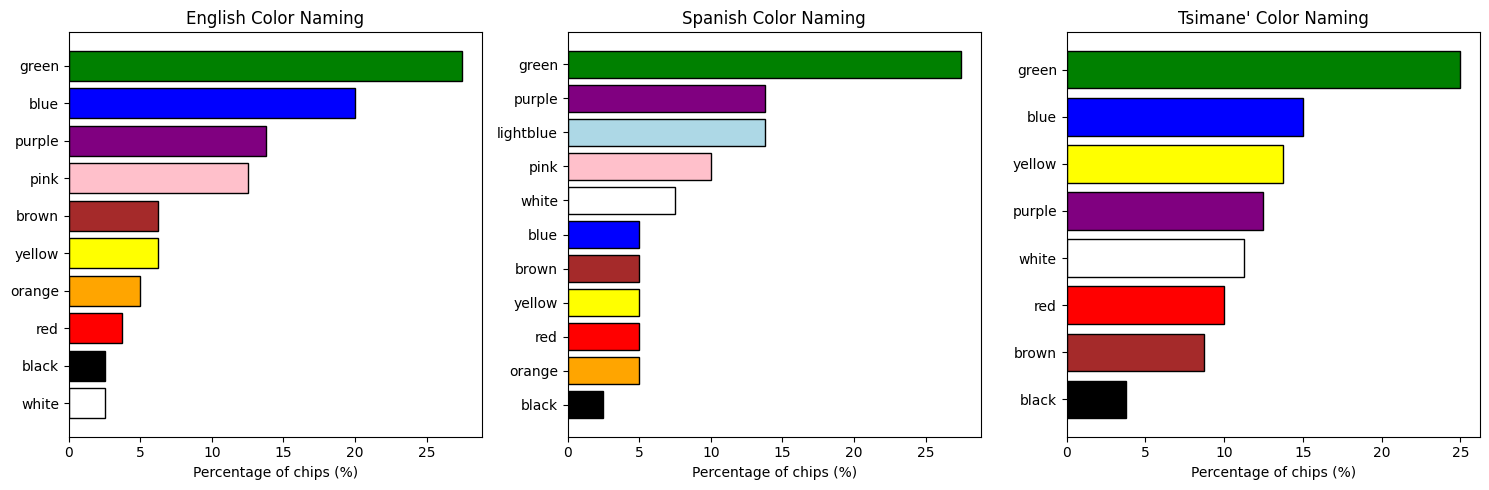

In [20]:
# Sort dataframes from smallest to biggest (so biggest appears at top in horizontal bar chart)
english_sorted = english_pct.sort_values('percentage', ascending=True)
spanish_sorted = spanish_pct.sort_values('percentage', ascending=True)
tsimane_sorted = tsimane_pct.sort_values('percentage', ascending=True)

# Create horizontal bar charts for each language
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# English bar chart
axes[0].barh(english_sorted['color'], english_sorted['percentage'],
             color=english_sorted['color'], edgecolor='black')
axes[0].set_xlabel('Porcentaje %')
axes[0].set_title('Ingles')

# Spanish bar chart
axes[1].barh(spanish_sorted['color'], spanish_sorted['percentage'],
             color=spanish_sorted['color'], edgecolor='black')
axes[1].set_xlabel('Porcentaje %')
axes[1].set_title('Español')

# Tsimane' bar chart
axes[2].barh(tsimane_sorted['color'], tsimane_sorted['percentage'],
             color=tsimane_sorted['color'], edgecolor='black')
axes[2].set_xlabel('Porcentaje %')
axes[2].set_title("Tsimane")

plt.tight_layout()
plt.show()

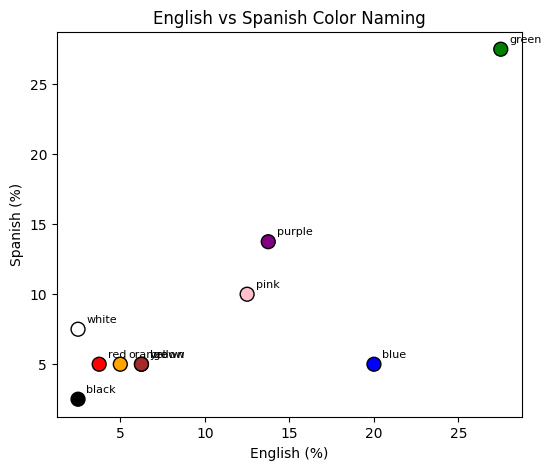

In [21]:
# Merge de dataframes de español e ingles
eng_spa = english_pct.merge(spanish_pct, on='color', suffixes=('_english', '_spanish'))

# Scatter plot
plt.figure(figsize=(6, 5))
plt.scatter(eng_spa['percentage_english'], eng_spa['percentage_spanish'],
            c=eng_spa['color'], edgecolors='black', s=100)

for _, row in eng_spa.iterrows():
    plt.annotate(row['color'], (row['percentage_english'] + 0.5, row['percentage_spanish'] + 0.5), fontsize=8)

plt.xlabel('Ingles (%)')
plt.ylabel('Español (%)')
plt.title('Ingles vs Español')
plt.show()

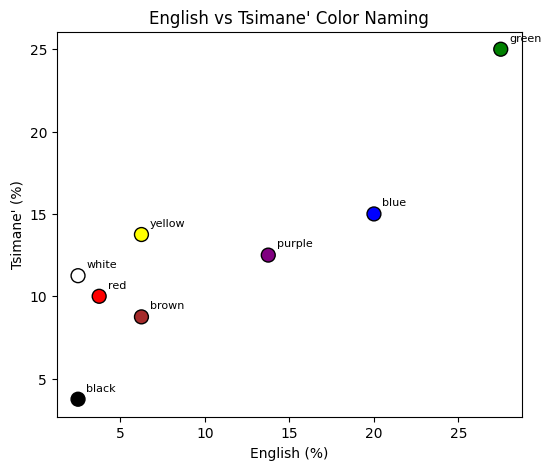

In [22]:
# Merge de dataframes de español e ingles
eng_tsi = english_pct.merge(tsimane_pct, on='color', suffixes=('_english', '_tsimane'))

# Scatter plot
plt.figure(figsize=(6, 5))
plt.scatter(eng_tsi['percentage_english'], eng_tsi['percentage_tsimane'],
            c=eng_tsi['color'], edgecolors='black', s=100)

for _, row in eng_tsi.iterrows():
    plt.annotate(row['color'], (row['percentage_english'] + 0.5, row['percentage_tsimane'] + 0.5), fontsize=8)

plt.xlabel('Ingles (%)')
plt.ylabel("Tsimane' (%)")
plt.title("Ingles vs Tsimane")
plt.show()


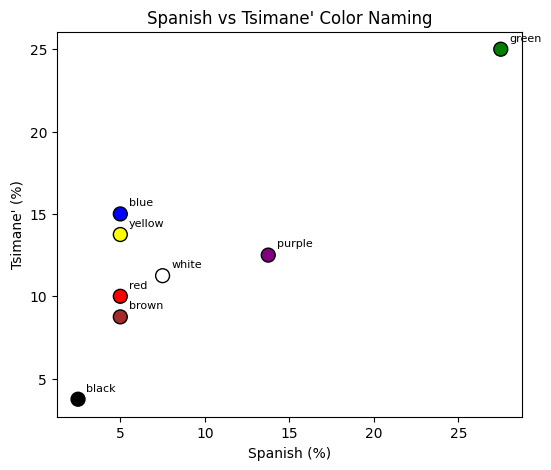

In [23]:
#Merge de dataframes de Tsimane y Espanñol
spa_tsi = spanish_pct.merge(tsimane_pct, on='color', suffixes=('_spanish', '_tsimane'))

# Scatter plot
plt.figure(figsize=(6, 5))
plt.scatter(spa_tsi['percentage_spanish'], spa_tsi['percentage_tsimane'],
            c=spa_tsi['color'], edgecolors='black', s=100)

for _, row in spa_tsi.iterrows():
    plt.annotate(row['color'], (row['percentage_spanish'] + 0.5, row['percentage_tsimane'] + 0.5), fontsize=8)

plt.xlabel('Español (%)')
plt.ylabel("Tsimane' (%)")
plt.title("Español vs Tsimane")
plt.show()